
=== L2 Regularization (C=0.01) - Underfitting ===
Accuracy: 0.83
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.78      0.81        72
           1       0.81      0.87      0.84        78

    accuracy                           0.83       150
   macro avg       0.83      0.82      0.83       150
weighted avg       0.83      0.83      0.83       150



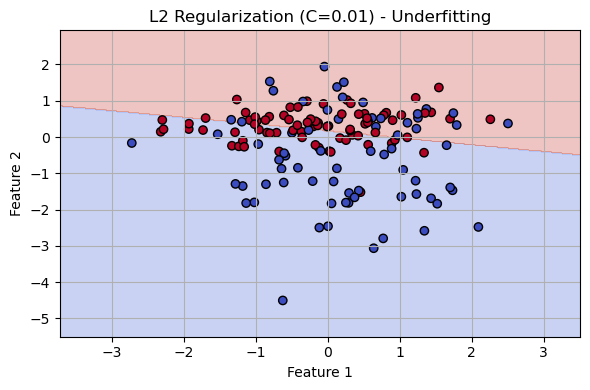


=== L2 Regularization (C=1) - Balanced ===
Accuracy: 0.83
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.81        72
           1       0.82      0.86      0.84        78

    accuracy                           0.83       150
   macro avg       0.83      0.83      0.83       150
weighted avg       0.83      0.83      0.83       150



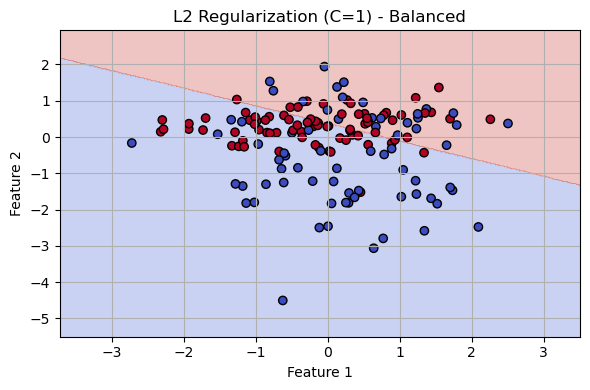


=== L2 Regularization (C=100) - Overfitting ===
Accuracy: 0.83
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.81        72
           1       0.82      0.86      0.84        78

    accuracy                           0.83       150
   macro avg       0.83      0.83      0.83       150
weighted avg       0.83      0.83      0.83       150



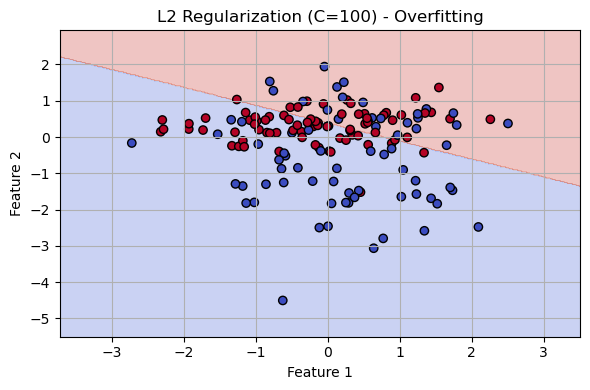


=== L1 Regularization (C=1) - Sparse Model ===
Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80        72
           1       0.80      0.85      0.82        78

    accuracy                           0.81       150
   macro avg       0.81      0.81      0.81       150
weighted avg       0.81      0.81      0.81       150



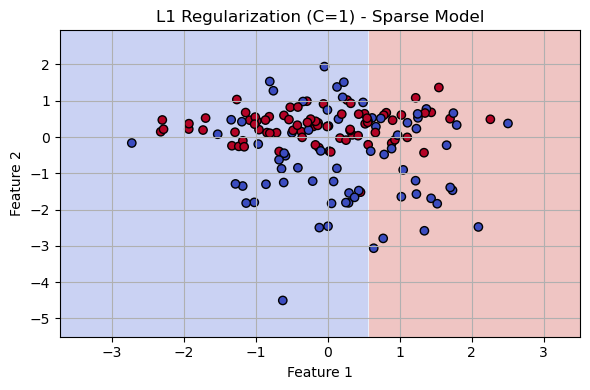

In [1]:
# Analyze model overfitting/underfitting with regularization (L1/L2). Include performance
# metrics.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------
# Step 1: Generate high-dimensional dataset
# ------------------------------------------------------
X, y = make_classification(
    n_samples=500,
    n_features=10,       # 10 total features
    n_informative=2,     # 2 features actually useful
    n_redundant=6,       # linear combinations (noise)
    n_clusters_per_class=1,
    class_sep=0.8,
    flip_y=0.1,          # 10% random label noise
    random_state=42
)

# ------------------------------------------------------
# Step 2: Train/Test Split
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ------------------------------------------------------
# Step 3: Feature Scaling
# ------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------
# Step 4: Evaluation & Decision Boundary Plot Function
# ------------------------------------------------------
def evaluate_model(penalty, C, title):
    model = LogisticRegression(
        penalty=penalty,
        C=C,
        solver='liblinear',
        max_iter=200
    )

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # ----- Metrics -----
    print(f"\n=== {title} ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # ----- Decision Boundary (using only first 2 features) -----
    x_min, x_max = X_test_scaled[:, 0].min() - 1, X_test_scaled[:, 0].max() + 1
    y_min, y_max = X_test_scaled[:, 1].min() - 1, X_test_scaled[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # Fill remaining features as zero
    n_features = X_train_scaled.shape[1]
    full_grid = np.zeros((grid.shape[0], n_features))
    full_grid[:, :2] = grid

    Z = model.predict(full_grid).reshape(xx.shape)

    # ----- Plot -----
    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
    plt.scatter(
        X_test_scaled[:, 0], X_test_scaled[:, 1],
        c=y_test, cmap=plt.cm.coolwarm,
        edgecolors='k'
    )
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.tight_layout()

    # Save image automatically
    filename = title.lower().replace(" ", "_").replace("(", "").replace(")", "") + ".png"
    plt.savefig(filename)

    plt.show()

# ------------------------------------------------------
# Step 6: Test different regularizations
# ------------------------------------------------------

# L2 Regularization (Ridge)
evaluate_model('l2', C=0.01, title='L2 Regularization (C=0.01) - Underfitting')
evaluate_model('l2', C=1,    title='L2 Regularization (C=1) - Balanced')
evaluate_model('l2', C=100,  title='L2 Regularization (C=100) - Overfitting')

# L1 Regularization (Lasso)
evaluate_model('l1', C=1,    title='L1 Regularization (C=1) - Sparse Model')
